# 01 — Exploratory Data Analysis
**Dataset:** Garbage Classification (Kaggle — asdasdasasdas)  
**Goal:** Understand the dataset structure, class distribution, image properties, and predefined splits before modeling.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from loguru import logger
from PIL import Image
from torchvision import transforms
from torchvision.datasets import ImageFolder

# Make project root importable
PROJ_ROOT = Path().resolve().parent
if str(PROJ_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJ_ROOT))

from garbage_classification.config import FIGURES_DIR, RAW_DATA_DIR
from garbage_classification.plots import plot_class_distribution, plot_sample_images

# Dataset path
DATASET_DIR = RAW_DATA_DIR / "Garbage classification" / "Garbage classification"
assert DATASET_DIR.exists(), f"Dataset not found at {DATASET_DIR}"

logger.info(f"Dataset path: {DATASET_DIR}")
logger.info(f"Figures will be saved to: {FIGURES_DIR}")

2026-03-28 13:20:48.856 | INFO     | garbage_classification.config:<module>:11 - PROJ_ROOT path is: C:\Users\PCROG\Desktop\Now\MLOps\wastenet_mlops


2026-03-28 13:20:48.863 | INFO     | __main__:<module>:25 - Dataset path: C:\Users\PCROG\Desktop\Now\MLOps\wastenet_mlops\data\raw\Garbage classification\Garbage classification
2026-03-28 13:20:48.865 | INFO     | __main__:<module>:26 - Figures will be saved to: C:\Users\PCROG\Desktop\Now\MLOps\wastenet_mlops\reports\figures


## 2. Class Distribution

In [2]:
# Count images per class
class_counts = {
    cls.name: len(list(cls.glob("*.jpg")) + list(cls.glob("*.png")))
    for cls in sorted(DATASET_DIR.iterdir())
    if cls.is_dir()
}

total = sum(class_counts.values())
print(f"Total images: {total}")
print(f"\nImages per class:")
for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"  {cls:12s}: {count:4d}  ({count/total*100:.1f}%)")

imbalance_ratio = max(class_counts.values()) / min(class_counts.values())
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.1f}x")

Total images: 2527

Images per class:
  paper       :  594  (23.5%)
  glass       :  501  (19.8%)
  plastic     :  482  (19.1%)
  metal       :  410  (16.2%)
  cardboard   :  403  (15.9%)
  trash       :  137  (5.4%)

Imbalance ratio (max/min): 4.3x


2026-03-28 13:20:49.500 | INFO     | garbage_classification.plots:plot_class_distribution:42 - Saved class distribution plot to C:\Users\PCROG\Desktop\Now\MLOps\wastenet_mlops\reports\figures\class_distribution.png


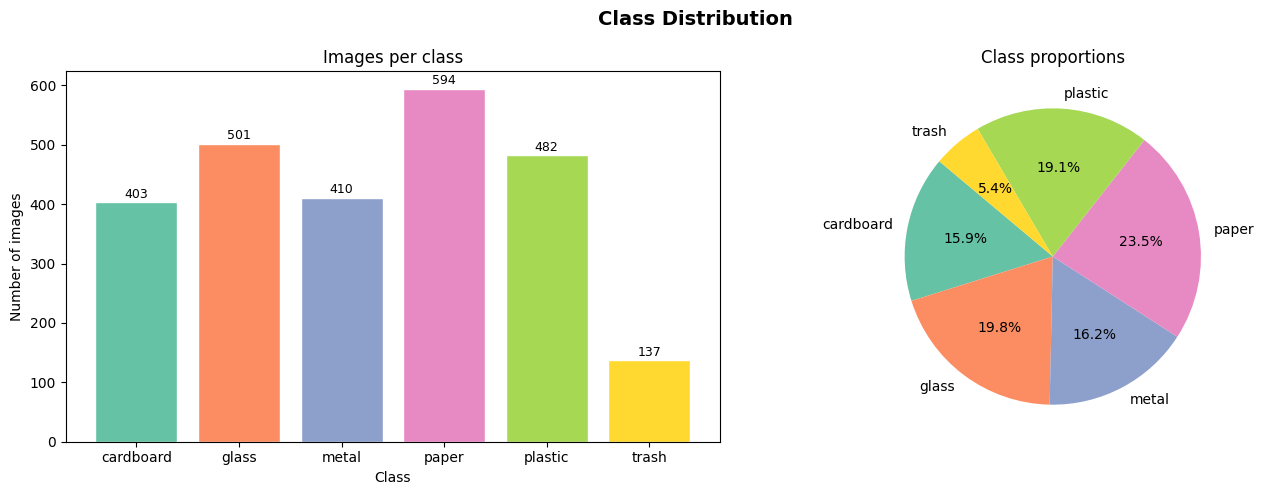

In [3]:
plot_class_distribution(class_counts, save_path=FIGURES_DIR / "class_distribution.png")

## 3. Sample Images

2026-03-28 13:20:50.783 | INFO     | garbage_classification.plots:plot_sample_images:93 - Saved sample images plot to C:\Users\PCROG\Desktop\Now\MLOps\wastenet_mlops\reports\figures\sample_images.png


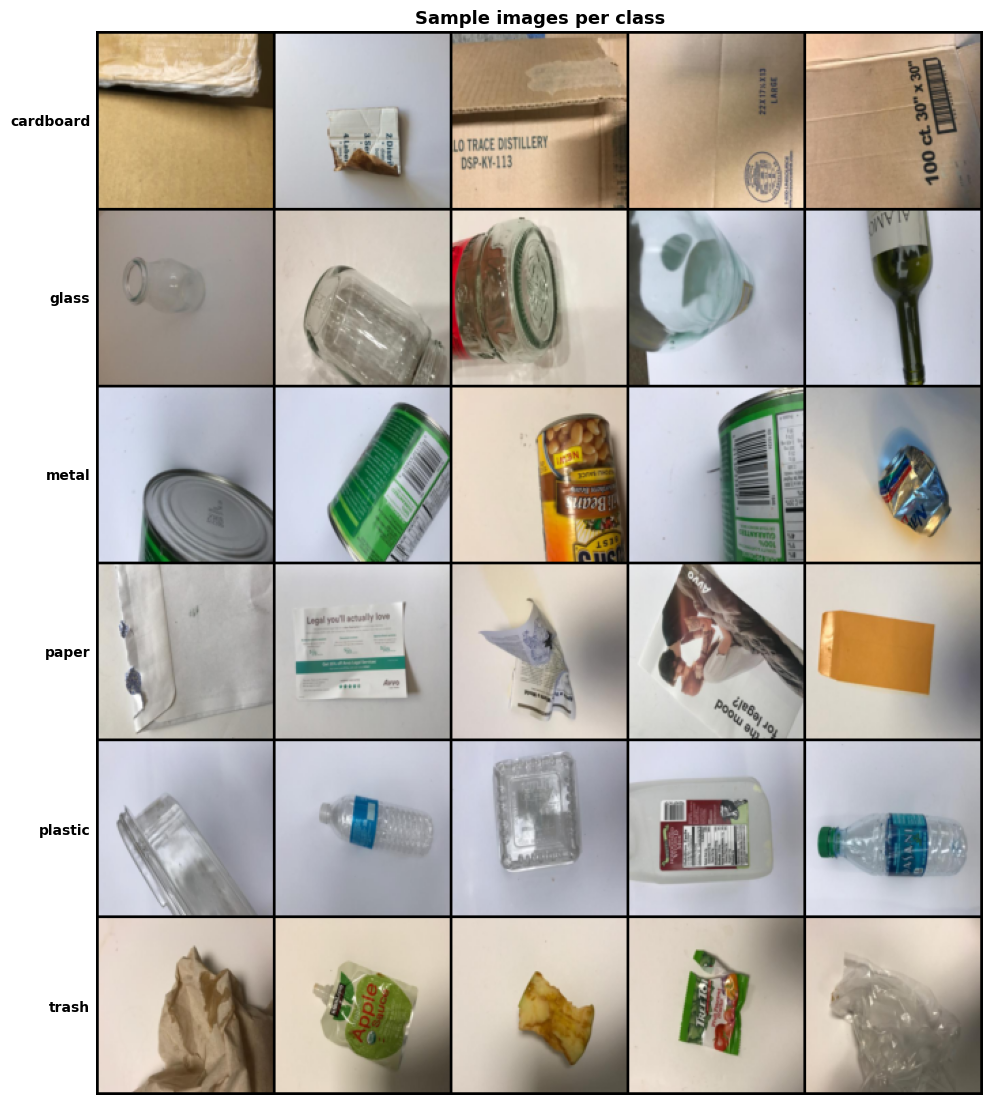

In [4]:
import random

random.seed(42)

to_tensor = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

N_PER_CLASS = 5
images_per_class = {}

for cls_dir in sorted(DATASET_DIR.iterdir()):
    if not cls_dir.is_dir():
        continue
    all_images = list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.png"))
    sampled = random.sample(all_images, min(N_PER_CLASS, len(all_images)))
    tensors = [to_tensor(Image.open(p).convert("RGB")) for p in sampled]
    images_per_class[cls_dir.name] = tensors

plot_sample_images(images_per_class, n_per_class=N_PER_CLASS, save_path=FIGURES_DIR / "sample_images.png")

## 4. Image Properties

In [5]:
records = []
corrupt = []

for cls_dir in sorted(DATASET_DIR.iterdir()):
    if not cls_dir.is_dir():
        continue
    for img_path in cls_dir.glob("*.jpg"):
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                mode = img.mode
            size_kb = img_path.stat().st_size / 1024
            records.append({
                "class": cls_dir.name,
                "filename": img_path.name,
                "width": w,
                "height": h,
                "aspect_ratio": w / h,
                "mode": mode,
                "size_kb": size_kb,
            })
        except Exception as e:
            corrupt.append((img_path, str(e)))

df = pd.DataFrame(records)
print(f"Total images scanned: {len(df)}")
print(f"Corrupt/unreadable  : {len(corrupt)}")
print(f"\nResolution stats:")
print(df[["width", "height", "aspect_ratio", "size_kb"]].describe().round(1))
print(f"\nColor modes: {df['mode'].value_counts().to_dict()}")

unique_resolutions = df.groupby(["width", "height"]).size().reset_index(name="count")
print(f"\nUnique resolutions: {len(unique_resolutions)}")
print(unique_resolutions.sort_values("count", ascending=False).head(10).to_string(index=False))

Total images scanned: 2527
Corrupt/unreadable  : 0

Resolution stats:
        width  height  aspect_ratio  size_kb
count  2527.0  2527.0        2527.0   2527.0
mean    512.0   384.0           1.3     16.7
std       0.0     0.0           0.0      7.4
min     512.0   384.0           1.3      5.5
25%     512.0   384.0           1.3     11.6
50%     512.0   384.0           1.3     15.0
75%     512.0   384.0           1.3     19.8
max     512.0   384.0           1.3     56.5

Color modes: {'RGB': 2527}

Unique resolutions: 1
 width  height  count
   512     384   2527


2026-03-28 13:20:54.376 | INFO     | __main__:<module>:29 - Saved resolution_distribution.png


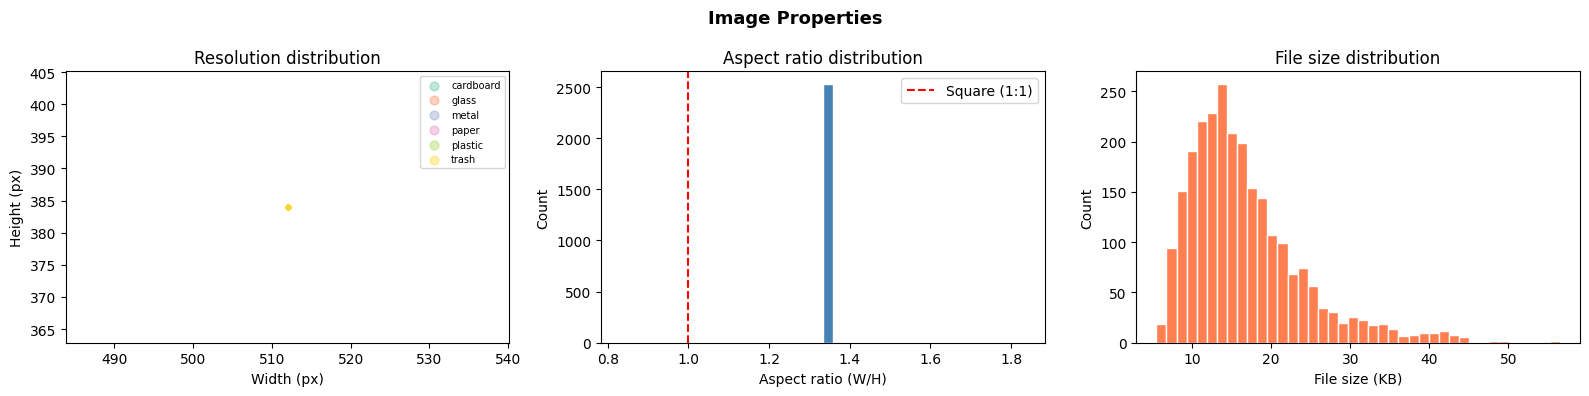

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Image Properties", fontsize=13, fontweight="bold")

# Resolution scatter
colors_map = {cls: plt.cm.Set2.colors[i] for i, cls in enumerate(df["class"].unique())}
for cls, grp in df.groupby("class"):
    axes[0].scatter(grp["width"], grp["height"], label=cls, alpha=0.4, s=10, color=colors_map[cls])
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].set_title("Resolution distribution")
axes[0].legend(fontsize=7, markerscale=2)

# Aspect ratio histogram
axes[1].hist(df["aspect_ratio"], bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(1.0, color="red", linestyle="--", label="Square (1:1)")
axes[1].set_xlabel("Aspect ratio (W/H)")
axes[1].set_ylabel("Count")
axes[1].set_title("Aspect ratio distribution")
axes[1].legend()

# File size
axes[2].hist(df["size_kb"], bins=40, color="coral", edgecolor="white")
axes[2].set_xlabel("File size (KB)")
axes[2].set_ylabel("Count")
axes[2].set_title("File size distribution")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "resolution_distribution.png", dpi=150, bbox_inches="tight")
logger.info("Saved resolution_distribution.png")
plt.show()

## 5. Color Analysis

In [7]:
RESIZE = (128, 128)
to_arr = transforms.Compose([transforms.Resize(RESIZE), transforms.ToTensor()])

class_rgb_means = {}

for cls_dir in sorted(DATASET_DIR.iterdir()):
    if not cls_dir.is_dir():
        continue
    img_paths = list(cls_dir.glob("*.jpg"))
    tensors = []
    for p in img_paths:
        try:
            t = to_arr(Image.open(p).convert("RGB"))
            tensors.append(t)
        except Exception:
            pass
    if tensors:
        stacked = torch.stack(tensors)  # (N, 3, H, W)
        class_rgb_means[cls_dir.name] = stacked.mean(dim=[0, 2, 3]).numpy()  # (3,)

print("Mean RGB values per class (0–1 scale):")
print(f"{'Class':12s}  {'R':>6}  {'G':>6}  {'B':>6}  {'Intensity':>10}")
for cls, rgb in sorted(class_rgb_means.items()):
    intensity = rgb.mean()
    print(f"{cls:12s}  {rgb[0]:.4f}  {rgb[1]:.4f}  {rgb[2]:.4f}  {intensity:.4f}")

Mean RGB values per class (0–1 scale):
Class              R       G       B   Intensity
cardboard     0.6670  0.5838  0.5017  0.5842
glass         0.6917  0.6687  0.6396  0.6667
metal         0.6464  0.6157  0.5957  0.6193
paper         0.6753  0.6453  0.6096  0.6434
plastic       0.6710  0.6671  0.6627  0.6669
trash         0.7012  0.6515  0.5845  0.6457


2026-03-28 13:21:01.702 | INFO     | __main__:<module>:38 - Saved color_analysis.png


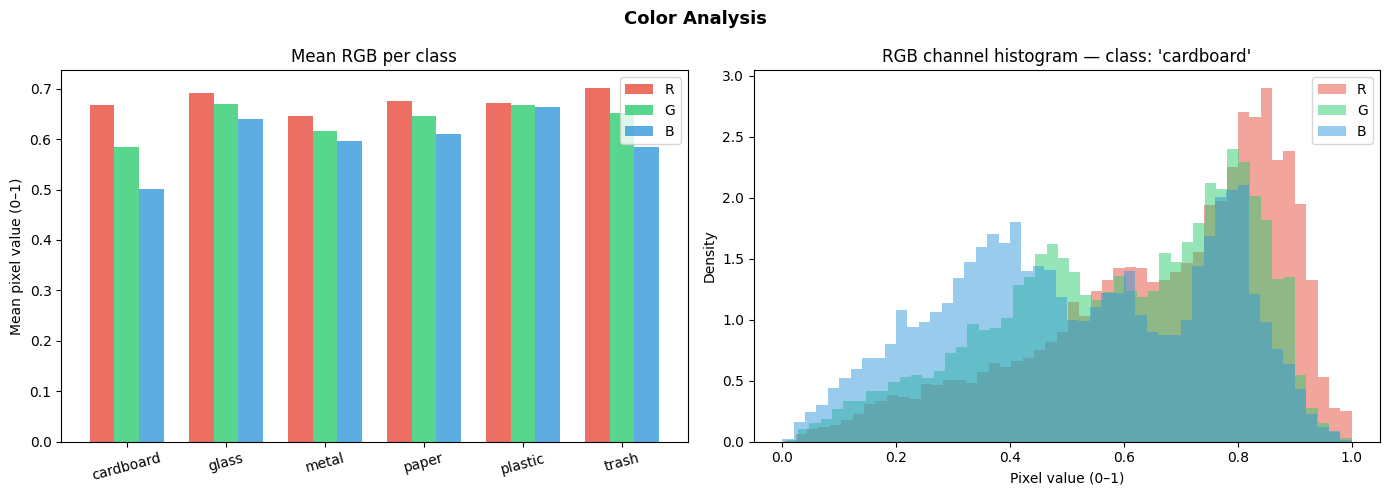

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Color Analysis", fontsize=13, fontweight="bold")

classes = list(class_rgb_means.keys())
r_vals = [class_rgb_means[c][0] for c in classes]
g_vals = [class_rgb_means[c][1] for c in classes]
b_vals = [class_rgb_means[c][2] for c in classes]

x = np.arange(len(classes))
w = 0.25
axes[0].bar(x - w, r_vals, w, label="R", color="#e74c3c", alpha=0.8)
axes[0].bar(x,     g_vals, w, label="G", color="#2ecc71", alpha=0.8)
axes[0].bar(x + w, b_vals, w, label="B", color="#3498db", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes, rotation=15)
axes[0].set_ylabel("Mean pixel value (0–1)")
axes[0].set_title("Mean RGB per class")
axes[0].legend()

# Pixel intensity per class (channel histograms — one class overlay)
channel_colors = {"R": "#e74c3c", "G": "#2ecc71", "B": "#3498db"}
cls_sample = classes[0]  # use first class as example
img_paths_sample = list((DATASET_DIR / cls_sample).glob("*.jpg"))[:50]
tensors_sample = [to_arr(Image.open(p).convert("RGB")) for p in img_paths_sample]
stacked_sample = torch.stack(tensors_sample)  # (N, 3, H, W)

for ch_idx, ch_name in enumerate(["R", "G", "B"]):
    pixels = stacked_sample[:, ch_idx, :, :].numpy().flatten()
    axes[1].hist(pixels, bins=50, alpha=0.5, label=ch_name, color=channel_colors[ch_name], density=True)

axes[1].set_xlabel("Pixel value (0–1)")
axes[1].set_ylabel("Density")
axes[1].set_title(f"RGB channel histogram — class: '{cls_sample}'")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "color_analysis.png", dpi=150, bbox_inches="tight")
logger.info("Saved color_analysis.png")
plt.show()

## 6. Dataset Splits (predefined train / val / test)

In [9]:
CLASS_MAP = pd.read_csv(RAW_DATA_DIR / "class_mapping.csv")
one_to_name = dict(zip(CLASS_MAP["one_indexed"], CLASS_MAP["class_name"]))

splits = {}
for split in ["train", "val", "test"]:
    txt_path = RAW_DATA_DIR / f"one-indexed-files-notrash_{split}.txt"
    if not txt_path.exists():
        logger.warning(f"Split file not found: {txt_path}")
        continue
    rows = []
    for line in txt_path.read_text().strip().splitlines():
        parts = line.strip().split()
        if len(parts) == 2:
            filename, label = parts[0], int(parts[1])
            rows.append({"filename": filename, "label": label, "class": one_to_name.get(label, "unknown")})
    splits[split] = pd.DataFrame(rows)

for split, df_split in splits.items():
    print(f"\n{split.upper()} — {len(df_split)} images")
    print(df_split["class"].value_counts().to_string())


TRAIN — 1768 images
class
paper        403
glass        354
plastic      347
cardboard    287
metal        286
trash         91

VAL — 328 images
class
paper        83
glass        65
plastic      61
metal        56
cardboard    46
trash        17

TEST — 431 images
class
paper        108
glass         82
plastic       74
cardboard     70
metal         68
trash         29



Images per class per split:
           train  val  test  total
class                             
cardboard    287   46    70    403
glass        354   65    82    501
metal        286   56    68    410
paper        403   83   108    594
plastic      347   61    74    482
trash         91   17    29    137


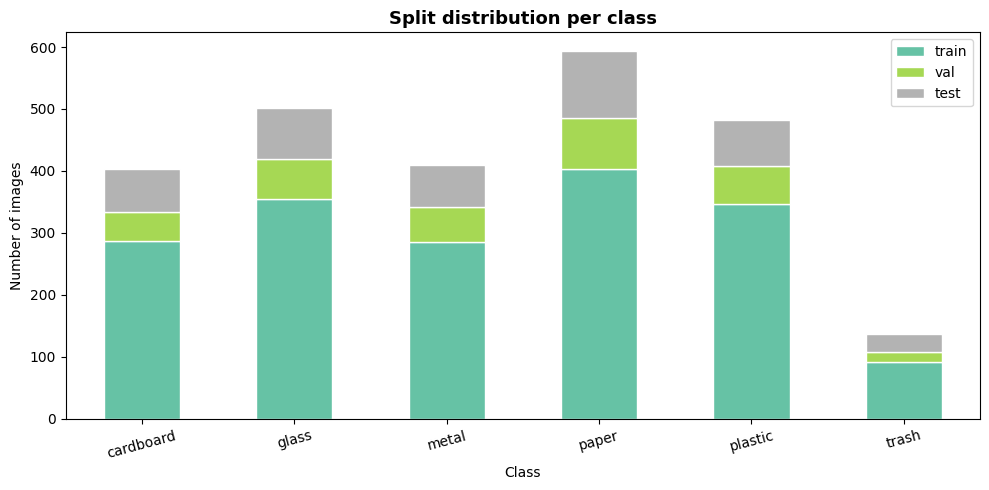

In [10]:
split_names = list(splits.keys())
classes_in_splits = sorted(splits[split_names[0]]["class"].unique())

split_matrix = pd.DataFrame(
    {split: splits[split]["class"].value_counts() for split in split_names}
).fillna(0).astype(int)
split_matrix["total"] = split_matrix.sum(axis=1)
print("\nImages per class per split:")
print(split_matrix.to_string())

# Stacked bar chart
ax = split_matrix[split_names].plot(
    kind="bar", stacked=True, figsize=(10, 5),
    colormap="Set2", edgecolor="white"
)
ax.set_title("Split distribution per class", fontsize=13, fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 7. Duplicate Images Detection

In [11]:
import hashlib
from collections import defaultdict

def image_hash(path: Path) -> str:
    """MD5 hash of a resized 8x8 grayscale thumbnail — fast perceptual fingerprint."""
    with Image.open(path) as img:
        thumb = img.convert("L").resize((8, 8), Image.LANCZOS)
        return hashlib.md5(thumb.tobytes()).hexdigest()

# Build hash → list of (class, filepath) mapping
hash_to_images = defaultdict(list)

for cls_dir in sorted(DATASET_DIR.iterdir()):
    if not cls_dir.is_dir():
        continue
    for img_path in cls_dir.glob("*.jpg"):
        h = image_hash(img_path)
        hash_to_images[h].append((cls_dir.name, img_path))

# All images with a hash that appears more than once
duplicates = {h: imgs for h, imgs in hash_to_images.items() if len(imgs) > 1}
dup_count = sum(len(v) - 1 for v in duplicates.values())

print(f"Unique hashes      : {len(hash_to_images)}")
print(f"Duplicate groups   : {len(duplicates)}")
print(f"Duplicate images   : {dup_count}  (extra copies)")

if duplicates:
    print("\nDuplicate groups (class: filename):")
    for h, imgs in list(duplicates.items())[:10]:
        entries = ", ".join(f"{cls}/{p.name}" for cls, p in imgs)
        print(f"  [{h[:8]}…] {entries}")
else:
    print("\nNo exact duplicates found.")

Unique hashes      : 2524
Duplicate groups   : 3
Duplicate images   : 3  (extra copies)

Duplicate groups (class: filename):
  [3e9c71f3…] glass/glass115.jpg, metal/metal91.jpg
  [af937b0e…] glass/glass176.jpg, plastic/plastic152.jpg
  [7f966f45…] glass/glass389.jpg, plastic/plastic332.jpg


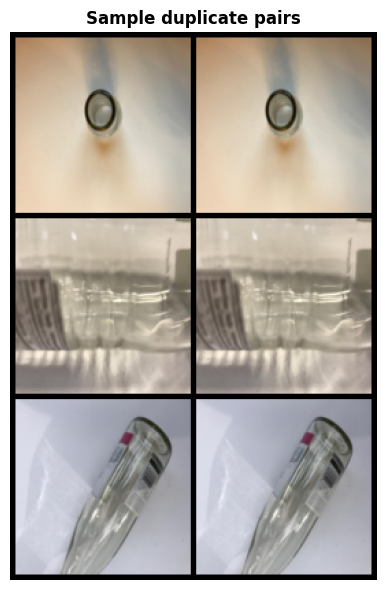

In [12]:
# Visualize one duplicate pair per group (up to 4 groups)
from torchvision.utils import make_grid

to_tensor_128 = transforms.Compose([transforms.Resize((128, 128)), transforms.ToTensor()])

if duplicates:
    dup_items = list(duplicates.items())[:4]
    pairs = []
    for h, imgs in dup_items:
        for _, p in imgs[:2]:
            pairs.append(to_tensor_128(Image.open(p).convert("RGB")))

    grid = make_grid(torch.stack(pairs), nrow=2, padding=4)
    fig, ax = plt.subplots(figsize=(6, len(dup_items) * 2))
    ax.imshow(grid.permute(1, 2, 0).numpy())
    ax.axis("off")
    ax.set_title("Sample duplicate pairs", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No duplicates to visualize.")

## 8. Train/Test Leakage Check

In [13]:
# --- Step 1: Filename intersection ---
split_filenames = {split: set(df_s["filename"]) for split, df_s in splits.items()}

leakage_filename = {}
split_pairs = [("train", "test"), ("train", "val"), ("val", "test")]
for s1, s2 in split_pairs:
    if s1 in split_filenames and s2 in split_filenames:
        overlap = split_filenames[s1] & split_filenames[s2]
        leakage_filename[f"{s1}↔{s2}"] = overlap

print("=== Step 1: Filename Intersection ===")
any_leak = False
for pair, overlap in leakage_filename.items():
    status = f"{len(overlap)} leaked files" if overlap else "OK"
    print(f"  {pair:15s}: {status}")
    if overlap:
        any_leak = True
        for f in list(overlap)[:5]:
            print(f"    → {f}")

if not any_leak:
    print("  No filename overlap found between splits.")

=== Step 1: Filename Intersection ===
  train↔test     : OK
  train↔val      : OK
  val↔test       : OK
  No filename overlap found between splits.


In [14]:
# --- Step 2: Hash intersection (catches renamed duplicates) ---
filename_to_hash = {
    p.name: h
    for h, imgs in hash_to_images.items()
    for _, p in imgs
}

# split → { hash: [filenames in that split] }
split_hash_to_files = {}
for split, fnames in split_filenames.items():
    mapping = {}
    for fn in fnames:
        if fn in filename_to_hash:
            h = filename_to_hash[fn]
            mapping.setdefault(h, []).append(fn)
    split_hash_to_files[split] = mapping

print("=== Step 2: Hash Intersection (content-based) ===")
any_hash_leak = False
hash_leaked_count = 0

for s1, s2 in split_pairs:
    if s1 not in split_hash_to_files or s2 not in split_hash_to_files:
        continue
    overlap_hashes = set(split_hash_to_files[s1]) & set(split_hash_to_files[s2])
    if overlap_hashes:
        any_hash_leak = True
        print(f"\n  {s1}↔{s2}: {len(overlap_hashes)} content match(es)")
        for h in overlap_hashes:
            files_s1 = split_hash_to_files[s1][h]
            files_s2 = split_hash_to_files[s2][h]
            print(f"    [{h[:8]}…]  {s1}: {files_s1}  ↔  {s2}: {files_s2}")
            hash_leaked_count += len(files_s1) + len(files_s2)
    else:
        print(f"  {s1}↔{s2}: OK")

# --- Leak ratio verdict ---
total_split_images = sum(len(df_s) for df_s in splits.values())
total_leaked = sum(len(v) for v in leakage_filename.values()) + hash_leaked_count
leak_ratio = total_leaked / total_split_images

print(f"\n=== Leakage Verdict ===")
print(f"  Leaked images       : {total_leaked} / {total_split_images}")
print(f"  Leak ratio          : {leak_ratio:.2%}")

if leak_ratio < 0.005:
    leakage_verdict = "LOW"
    print("  Leakage risk: LOW ✓  (< 0.5%)")
elif leak_ratio < 0.02:
    leakage_verdict = "MEDIUM"
    print("  Leakage risk: MEDIUM ⚠  (0.5–2%) — review before training")
else:
    leakage_verdict = "HIGH"
    print("  Leakage risk: HIGH ✗  (> 2%) — re-split the dataset")

=== Step 2: Hash Intersection (content-based) ===

  train↔test: 1 content match(es)
    [af937b0e…]  train: ['glass176.jpg']  ↔  test: ['plastic152.jpg']

  train↔val: 1 content match(es)
    [7f966f45…]  train: ['glass389.jpg']  ↔  val: ['plastic332.jpg']
  val↔test: OK

=== Leakage Verdict ===
  Leaked images       : 4 / 2527
  Leak ratio          : 0.16%
  Leakage risk: LOW ✓  (< 0.5%)


## 9. Summary & Key Findings

In [16]:
most_common_res = df.groupby(["width", "height"]).size().idxmax()

print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Total images        : {len(df)}")
print(f"Number of classes   : {len(class_counts)}")
print(f"Corrupt images      : {len(corrupt)}")
print(f"")
print(f"Class imbalance     : {imbalance_ratio:.1f}x  ({min(class_counts, key=class_counts.get)}: {min(class_counts.values())} vs {max(class_counts, key=class_counts.get)}: {max(class_counts.values())})")
print(f"")
print(f"Most common res.    : {most_common_res[0]}×{most_common_res[1]} px")
print(f"Median file size    : {df['size_kb'].median():.1f} KB")
print(f"")
print(f"Duplicate groups    : {len(duplicates)}  ({dup_count} extra copies)")
print(f"Leaked images       : {total_leaked} / {total_split_images}  (leak ratio: {leak_ratio:.2%})")
print(f"Leakage risk        : {leakage_verdict}")
print(f"")
print("Predefined splits:")
for split, df_split in splits.items():
    print(f"  {split:5s}: {len(df_split)} images")
print("")
print("Action items:")
print(f"  - Handle class imbalance (trash only {min(class_counts.values())} images)")
if len(corrupt) > 0:
    print(f"  - Remove {len(corrupt)} corrupt images from the pipeline")
if dup_count > 0:
    print(f"  - Review {len(duplicates)} duplicate groups ")

DATASET SUMMARY
Total images        : 2527
Number of classes   : 6
Corrupt images      : 0

Class imbalance     : 4.3x  (trash: 137 vs paper: 594)

Most common res.    : 512×384 px
Median file size    : 15.0 KB

Duplicate groups    : 3  (3 extra copies)
Leaked images       : 4 / 2527  (leak ratio: 0.16%)
Leakage risk        : LOW

Predefined splits:
  train: 1768 images
  val  : 328 images
  test : 431 images

Action items:
  - Handle class imbalance (trash only 137 images)
  - Review 3 duplicate groups 
